# リスクがない時のライフサイクルモデルを解く

各年齢でオイラー方程式が成り立つような、各年齢の資産保有量を求める。
具体的には、オイラー方程式の両辺を比べる関数を作って、それが各年齢でちゃんと0になるような各年齢の資産保有量を求める。

In [1]:
using NLsolve
using Plots
using LaTeXStrings

In [2]:
# create constructer that contains parameters
struct Model{TI<:Integer, TF<:AbstractFloat}
    
    alpha::TF      
    del::TF          
    beta::TF           
    Nj::TI        
    Njw::TI                
    rho::TF              
    meaJ::Array{TF,1}
    theta::Array{TF,1}
    L::TF
    ss0::Array{TF,1}
    tau::TF

end


In [3]:
ind_E = 1;
    # =1 BASELINE
    # =2 rho 50% down
    # =3 raise NRA TO 70
    # =4 live up to 85

# parameters
alpha = 0.40;
del = 0.08;
beta = 0.98;
Nj = 61;  # live 60 years max
Njw = 45; # working years (retires at Njw+1) : enter at 21 and retire at 65
rho = 0.5 # SS replacement rate (0.0 or 0.5)

meaJ = (1/Nj) .* ones(Nj); # age distribution (no population growth)


In [4]:

if ind_E == 2
    rho = 0.25;
end

if ind_E == 3
    Njw = 50;
end

if ind_E == 4
    Nj = 66;
    meaJ = (1/Nj) .* ones(Nj); # in experiment to raise longevity
end

# labor productivity
theta = zeros(Nj);
theta[1:Njw] .= 1.0;

# aggregate labor supply
L = sum(meaJ[1:Njw] .* theta[1:Njw]);

# pension (social security)
ss0 = zeros(Nj);
ss0[Njw+1:Nj] .= rho;

# pension replacement rate
tau = rho*(Nj-Njw)/Njw;


In [5]:
m = Model(alpha,del,beta,Nj,Njw,rho,meaJ,theta,L,ss0,tau);

In [6]:
# initial guess for asset decisions
a_g = zeros(Nj-1); # a[2] to a[Nj] (NOTE: a[1]=a[Nj+1]=0) 
a_g[1] = 0.01;
for j in 1:m.Nj-2
    a_g[j+1] = a_g[j] + 0.01;
end


### 各期でのオイラー方程式を満たすような政策関数を求める

ここでは、以下を満たすような政策関数を見つける：

- 各期でのオイラー方程式が満たされている
- 最終期の資産が0になる

実際には、単に上の二つを満たすような$\{a_j\}_{j=1}^{J}$を見つける、ということをしている。
状態変数は$a$と$j$だけなので、$\{a_j\}_{j=1}^{J}$がわかれば$a_{j+1} = a'(a_j, j)$がわかる、ということである。

In [7]:
function policyA(m,aX)
    """
    --------------------------------------------------------------
    === Returns Euler Equation Error given HH's Asset Profile ===
    --------------------------------------------------------------
    ※THIS SHOULD BE ZERO AT EQUILIBRIUM
    <input>
    ・m: model structure 
    ・aX: HH's asset profile(from age 2 to Nj -> (Nj-2+1) element vector)
    <output>
    ・f: Euler equation errors from age 1 to Nj-1 -> (Nj-1+1) element vector
    """

    # sequence of asset holdings (a[1] to a[Nj+1])
    # NOTE: a[1]=a[Nj+1]=0 (initial and terminal asset)
    a = zeros(m.Nj+1);
    # initial asset
    a[1] = 0.0;
    a[m.Nj+1] = 0.0;

    a[2:m.Nj] .= copy(aX);

    K = sum(a[1:end-1] .* m.meaJ); 

    r = m.alpha * (K/m.L)^(m.alpha-1) - m.del; # interest rate
    w = (1-m.alpha)*(K/m.L)^m.alpha; # wage

    ss = m.ss0.*w;

    # euler equation (u(c)=log(c))
    f = zeros(m.Nj-1)
    for j in 1:m.Nj-1
        # beta*(1+r)*c
        ff =  m.beta * (1+r) * ((1+r)*a[j] + w*m.theta[j]*(1-m.tau) + ss[j] - a[j+1]);
        # 0=c'-ff
        f[j] = (1+r)*a[j+1] + w*theta[j+1]*(1-m.tau) + ss[j+1] - a[j+2] - ff;
    end

    return f
end

policyA (generic function with 1 method)

In [22]:
# find solutions: aX[2:Nj]
aX = nlsolve(x->policyA(m,x),a_g).zero;

In [23]:
a = zeros(m.Nj+1);
a[2:m.Nj] .= copy(aX);

K = sum(a[1:end-1] .* m.meaJ);

r = m.alpha * (K/L)^(m.alpha-1) - m.del; # interest rate
w = (1-m.alpha) * (K/L)^m.alpha; # wage

ss = ss0 .* w;

c = zeros(m.Nj);
for j in 1:m.Nj
    c[j] = w*m.theta[j]*(1-m.tau) + (1+r)*a[j] + ss[j] - a[j+1];
end

ageA = collect(1:Nj+1);
ageA .+= 19;

ageC = collect(1:Nj);
ageC .+= 19;

minJ = 20;
maxJ = 19 + m.Nj;

norm = c[1];

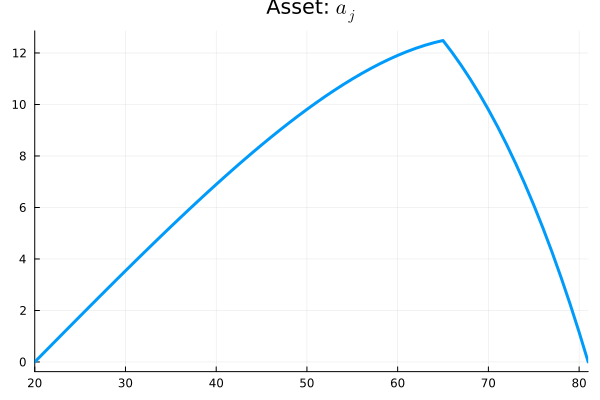

In [99]:
plot(ageA,a/norm,lw=3,legend=false)
title!(L"Asset: $a_{j}$")
xlims!(minJ,maxJ + 1)

## より教科書の記述に従った解き方

教科書（p.149）では、所与の総資産 $K_0$ から要素価格を計算し各年齢のオイラー方程式と予算制約式から各年齢の消費と資産を計算して、そこから計算された総資産と最初に設定した資産 $K_0$ の差が小さくなるよう（資産市場がきちんと均衡するよう）な $K_0$を求める、という手続きを説明している。
以下では、この方法により忠実に従った計算方法でモデルを解いている。

また、各期の消費については教科書の式 (6.3), (6.4) を使って解析的に求めている。

In [145]:
function calculate_asset(m, K)
    # calculate interest rate from capital stock
    r = m.alpha * (K/m.L)^(m.alpha - 1) - m.del;
    # calculate wage from capital stock
    w = (1 - m.alpha) * (K/m.L)^m.alpha;

    # sequence of asset holdings (a[1] to a[Nj+1])
    a = zeros(m.Nj+1);
    # initial asset
    a[1] = 0.0;

    # pension benefits after retirement
    ss = m.ss0 .* w;

    # present value of lifetime labor income
    Y = sum((m.theta .* w .* (1 - m.tau) .+ ss) ./ (1 + r).^range(0, m.Nj - 1));
    # consumption growth rate
    g_c = (m.beta * (1 + r)) - 1;


    c = zeros(m.Nj+1);
    # 1st period consumption
    c[1] = Y / sum(
        ((1 + g_c) / (1 + r)).^range(0, m.Nj - 1)
    )
    # consumption and asset for each age (from age 2 to age Nj)
    for j in 1:m.Nj-1
        a[j+1] = (1 + r) * a[j] + m.theta[j] * w * (1 - m.tau) - c[j] + ss[j];
        c[j+1] = (1 + g_c) * c[j];
    end

    return a, c, r, w
end

calculate_asset (generic function with 1 method)

In [146]:
function calculate_asset_diff(m, K)

    a = calculate_asset(m, K)[1]

    return K - sum(a[1:end-1] .* m.meaJ)

end

calculate_asset_diff (generic function with 1 method)

In [147]:
res = find_zero(K -> calculate_asset_diff(m, K), (0.01, 10.0))

6.116627636859023

In [150]:
a, c, r, w = calculate_asset(m, res);

In [154]:
res / (res^m.alpha * m.L^(1-m.alpha))

3.557767948931169

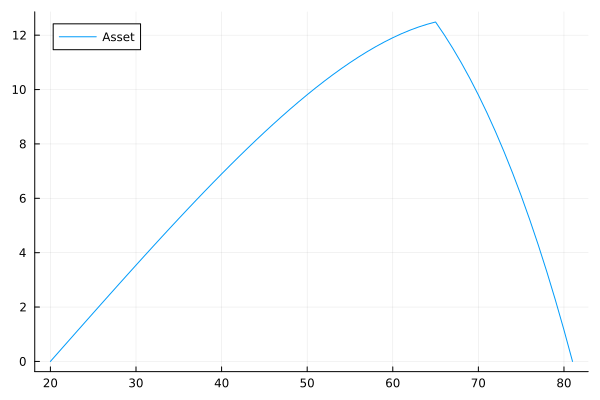

In [152]:
plot(ageA, a / c[1], label="Asset")

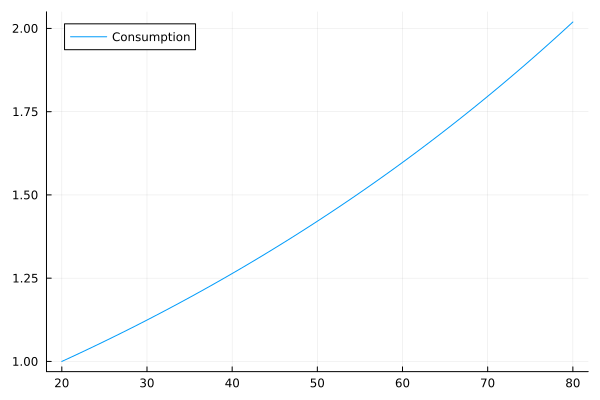

In [136]:
plot(ageA[1:end-1], c[1:end-1] / c[1], label="Consumption")